In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf


In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

In [3]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [4]:
dataset_path = "brain_tumor_dataset"


In [5]:
train_path ="C:/Users/Ganesh/Downloads/archive (4)/Training"
test_path = "C:/Users/Ganesh/Downloads/archive (4)/Testing"


In [6]:
IMG_SIZE = 224
BATCH_SIZE = 32


In [7]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)




In [10]:
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 2236 images belonging to 4 classes.
Found 558 images belonging to 4 classes.


In [11]:
print("Classes:", train_data.class_indices)


Classes: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [12]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [13]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),

    Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.5),

    Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.5),

    Dense(train_data.num_classes, activation='softmax')
])

In [14]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,619,332 (9.99 MB)

 Trainable params: 361,348 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    callbacks=[early_stop, reduce_lr, checkpoint]
)


Epoch 1/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4003 - loss: 2.1411
Epoch 1: val_accuracy improved from None to 0.69534, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.4638 - loss: 1.9220 - val_accuracy: 0.6953 - val_loss: 1.4514 - learning_rate: 1.0000e-04
Epoch 2/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5991 - loss: 1.5508
Epoch 2: val_accuracy improved from 0.69534 to 0.78136, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.6145 - loss: 1.5055 - val_accuracy: 0.7814 - val_loss: 1.2015 - learning_rate: 1.0000e-04
Epoch 3/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6718 - loss: 1.3587
Epoch 3: val_accuracy improved from 0.78136 to 0.78674, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.6847 - loss: 1.3393 - val_accuracy: 0.7867 - val_loss: 1.1024 - learning_rate: 1.0000e-04
Epoch 4/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7262 - loss: 1.2427
Epoch 4: val_accuracy improved from 0.78674 to 0.82437, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.7312 - loss: 1.2369 - val_accuracy: 0.8244 - val_loss: 1.0284 - learning_rate: 1.0000e-04
Epoch 5/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7643 - loss: 1.1332
Epoch 5: val_accuracy improved from 0.82437 to 0.84409, saving model to best_model.h5


...


Epoch 9: finished saving model to best_model.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.8162 - loss: 0.9776 - val_accuracy: 0.8638 - val_loss: 0.8661 - learning_rate: 1.0000e-04
Epoch 10/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8266 - loss: 0.9529
Epoch 10: val_accuracy improved from 0.86380 to 0.87993, saving model to best_model.h5



Epoch 10: finished saving model to best_model.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.8242 - loss: 0.9545 - val_accuracy: 0.8799 - val_loss: 0.8456 - learning_rate: 1.0000e-04
Epoch 11/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8323 - loss: 0.9415
Epoch 11: val_accuracy did not improve from 0.87993
70/70 ━━━━━━━━━━━━━━━━━━━━ 232s 3s/step - accuracy: 0.8283 - loss: 0.9448 - val_accuracy: 0.8638 - val_loss: 0.8459 - learning_rate: 1.0000e-04
Epoch 12/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8426 - loss: 0.9076
Epoch 12: val_accuracy did not improve from 0.87993
70/70 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - accuracy: 0.8359 - loss: 0.9142 - val_accuracy: 0.8602 - val_loss: 0.8343 - learning_rate: 1.0000e-04
Epoch 13/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8374 - loss: 0.9116
Epoch 13: val_accuracy did not improve from 0.87993
70/70 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.8318 - loss: 0.9102 - val_accuracy: 0.8692 - val_loss: 0


Epoch 15: finished saving model to best_model.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 374s 2s/step - accuracy: 0.8600 - loss: 0.8449 - val_accuracy: 0.8889 - val_loss: 0.7870 - learning_rate: 1.0000e-04
Epoch 16/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8581 - loss: 0.8349
Epoch 16: val_accuracy improved from 0.88889 to 0.90143, saving model to best_model.h5



Epoch 16: finished saving model to best_model.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.8564 - loss: 0.8367 - val_accuracy: 0.9014 - val_loss: 0.7641 - learning_rate: 1.0000e-04
Epoch 17/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.8624 - loss: 0.8232
Epoch 17: val_accuracy did not improve from 0.90143
70/70 ━━━━━━━━━━━━━━━━━━━━ 490s 7s/step - accuracy: 0.8538 - loss: 0.8286 - val_accuracy: 0.8943 - val_loss: 0.7628 - learning_rate: 1.0000e-04
Epoch 18/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8597 - loss: 0.8102
Epoch 18: val_accuracy did not improve from 0.90143
70/70 ━━━━━━━━━━━━━━━━━━━━ 329s 5s/step - accuracy: 0.8582 - loss: 0.8082 - val_accuracy: 0.8907 - val_loss: 0.7381 - learning_rate: 1.0000e-04
Epoch 19/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8646 - loss: 0.8101
Epoch 19: val_accuracy did not improve from 0.90143
70/70 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.8631 - loss: 0.8025 - val_accuracy: 0.8638 - val_loss: 0


Epoch 23: finished saving model to best_model.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.8734 - loss: 0.7539 - val_accuracy: 0.9032 - val_loss: 0.6857 - learning_rate: 1.0000e-04
Epoch 24/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8613 - loss: 0.7716
Epoch 24: val_accuracy did not improve from 0.90323
70/70 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.8792 - loss: 0.7335 - val_accuracy: 0.8961 - val_loss: 0.6923 - learning_rate: 1.0000e-04
Epoch 25/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8811 - loss: 0.7174
Epoch 25: val_accuracy did not improve from 0.90323
70/70 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.8828 - loss: 0.7205 - val_accuracy: 0.8943 - val_loss: 0.6831 - learning_rate: 1.0000e-04


In [17]:
predictions = model.predict(test_data)
pred_classes = np.argmax(predictions, axis=1)

true_classes = test_data.classes
class_labels = list(test_data.class_indices.keys())




50/50 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step


In [18]:
print("\nClassification Report:\n")

print(classification_report(
    true_classes,
    pred_classes,
    target_names=class_labels
))




Classification Report:

              precision    recall  f1-score   support

      glioma       0.90      0.70      0.79       400
  meningioma       0.77      0.71      0.74       400
     notumor       0.91      0.97      0.94       400
   pituitary       0.81      1.00      0.89       400

    accuracy                           0.85      1600
   macro avg       0.85      0.85      0.84      1600
weighted avg       0.85      0.85      0.84      1600



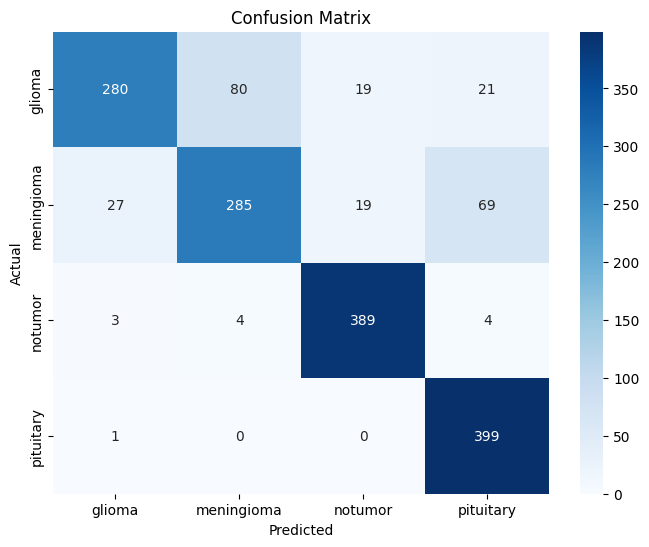

In [19]:
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()




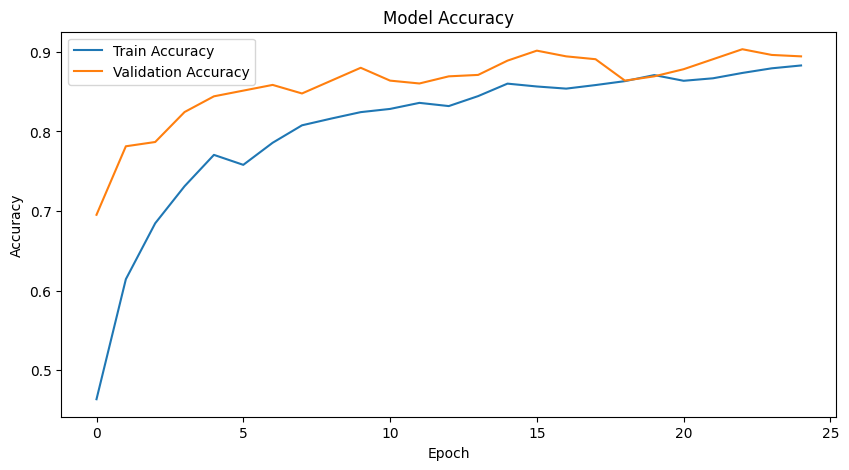

In [20]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.show()


In [21]:
model.save("brain_tumor_model.h5")

print("\nModel Saved Successfully!")



Model Saved Successfully!


In [22]:
model.save("brain_tumor_model.h5")

print("\nModel Saved Successfully!")



Model Saved Successfully!


In [23]:
from tensorflow.keras.preprocessing import image

img_path =  "C:/Users/Ganesh/Downloads/archive (4)/Testing/glioma/Te-gl_95.jpg"
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

predicted_class = class_labels[np.argmax(prediction)]

print("\nPredicted Class:", predicted_class)





1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step

Predicted Class: glioma


In [24]:
pip install gradio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\Ganesh\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [1]:
import gradio as gr
import tensorflow as tf
from PIL import Image
import numpy as np

model = tf.keras.models.load_model("brain_tumor_model.h5")

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

def predict(image):
    image = image.resize((224,224))
    image = np.array(image) / 255.0
    image = np.expand_dims(image, axis=0)

    prediction = model.predict(image)

    class_index = np.argmax(prediction)
    return class_names[class_index]

demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs="text"
)

demo.launch()

C:\Users\Ganesh\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step


In [26]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "C:/Users\Ganesh\Downloads/brain_tumor_img.jpg"  # your MRI image

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print(prediction)
print("Predicted class:", np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
[[2.3067356e-04 6.1545162e-03 9.9202675e-01 1.5880108e-03]]
Predicted class: 2


In [27]:
print(train_generator.class_indices)


NameError: name 'train_generator' is not defined

In [29]:
print(train_data.class_indices)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "C:\Users\Ganesh\AppData\Local\Programs\Python\Python311\Lib\site-packages\uvicorn\protocols\http\httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Ganesh\AppData\Local\Programs\Python\Python311\Lib\site-packages\uvicorn\middleware\proxy_headers.py", line 62, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Ganesh\AppData\Local\Programs\Python\Python311\Lib\site-packages\fastapi\applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "C:\Users\Ganesh\AppData\Local\Programs\Python\Python311\Lib\site-packages\starlette\applications.py", line 90, in __call__
    await self.middleware_stack(scope, receive, send)
  File "C:\Users\Ganesh\AppData\Local\Programs\Python\Py

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step


In [30]:
print(train_data.class_indices)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [31]:
prediction = model.predict(img_array)
print(prediction)
print(np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
[[2.3067356e-04 6.1545162e-03 9.9202675e-01 1.5880108e-03]]
2


In [32]:
print("Train Accuracy:", history.history['accuracy'][-1])
print("Val Accuracy:", history.history['val_accuracy'][-1])

Train Accuracy: 0.8828264474868774
Val Accuracy: 0.8942652344703674


FileNotFoundError: [Errno 2] No such file or directory: 'brain_tumor_dataset/Testing/glioma/your_image.jpg'